<a href="https://colab.research.google.com/github/analicardoza074/pokemon-data/blob/main/Take2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Switching gears Pokemon Legendary Status Classifier
#Main goal is to predict whether a Pokemon is Legendary (1) or Regular(0) using Numerical battle stats and characteristics
#Imports!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests
from io import BytesIO
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("✓ All libraries loaded.")
print(f"  PyTorch version : {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Device          : {device}")


✓ All libraries loaded.
  PyTorch version : 2.10.0+cpu
  Device          : cpu


In [ ]:
#Load and Explore dataset
df = pd.read_csv("https://raw.githubusercontent.com/analicardoza074/pokemon-data/refs/heads/main/pokemon.csv")
print(df.shape)
print(f"\nDataset loaded successfully.")
print(f"  Total Pokémon : {len(df)}")
print(f"  Total columns : {len(df.columns)}")

(801, 41)

Dataset loaded successfully.
  Total Pokémon : 801
  Total columns : 41


In [ ]:
# a sanity check that the file loaded
# correctly and the columns look as expected
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
                     abilities  against_bug  against_dark  against_dragon  \
0  ['Overgrow', 'Chlorophyll']          1.0           1.0             1.0   
1  ['Overgrow', 'Chlorophyll']          1.0           1.0             1.0   
2  ['Overgrow', 'Chlorophyll']          1.0           1.0             1.0   
3     ['Blaze', 'Solar Power']          0.5           1.0             1.0   
4     ['Blaze', 'Solar Power']          0.5           1.0             1.0   

   against_electric  against_fairy  against_fight  against_fire  \
0               0.5            0.5            0.5           2.0   
1               0.5            0.5            0.5           2.0   
2               0.5            0.5            0.5           2.0   
3               1.0            0.5            1.0           0.5   
4               1.0            0.5            1.0           0.5   

   against_flying  against_ghost  ...  percentage_male  pokedex_number  \
0             2.0            1.0  ...        

In [ ]:
print(f"\nLegendary vs Regular:")
print(df["is_legendary"].value_counts())
print(f"Legendary rate: {df['is_legendary'].mean()*100:.1f}% of all Pokémon")


Legendary vs Regular:
is_legendary
0    731
1     70
Name: count, dtype: int64
Legendary rate: 8.7% of all Pokémon


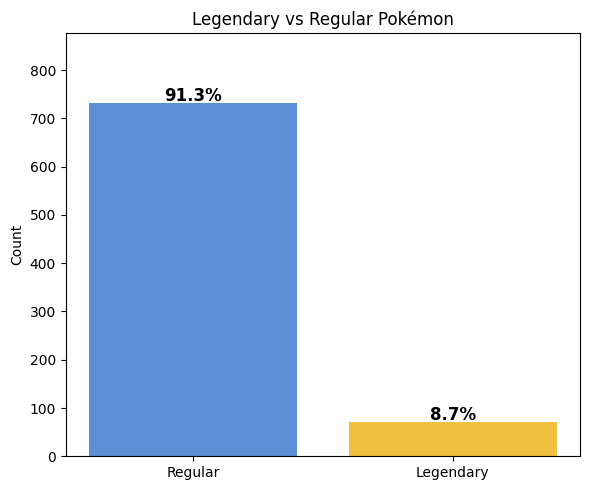

In [ ]:

counts = df["is_legendary"].value_counts().sort_index()

labels = ["Regular", "Legendary"]
values = [counts[0], counts[1]]

plt.figure(figsize=(6, 5))
colors = ["#5a8fd4", "#f0c040"]  # blue = regular, gold = legendary
bars = plt.bar(labels, values, color=colors)

# Want to add percentage for easy visual
total = sum(values)
for bar, val in zip(bars, values):
    pct = val / total * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f"{pct:.1f}%",
             ha='center', fontsize=12, fontweight='bold')

plt.title("Legendary vs Regular Pokémon")
plt.ylabel("Count")
plt.ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.show()

Clearly more Regular than Legendary Pokemon. but Legendary have higher stats. So I need to have the model recognize the gap and make sure it can learn and predict accordingly.

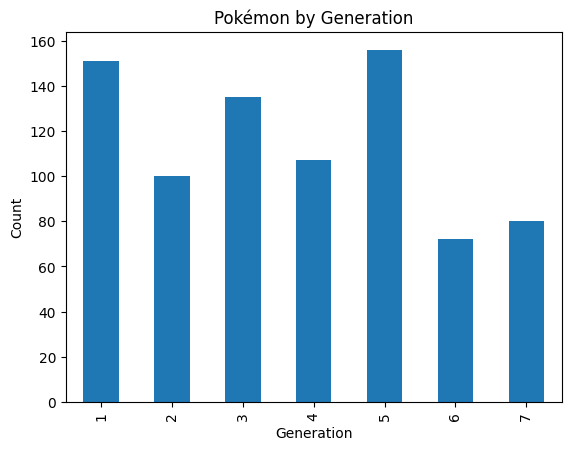

In [ ]:
df["generation"].value_counts().sort_index().plot(kind="bar", title="Pokémon by Generation")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.show()
#It includes Pokémon from Gen 1 all the way to Gen 7, so the model learns patterns across the whole series

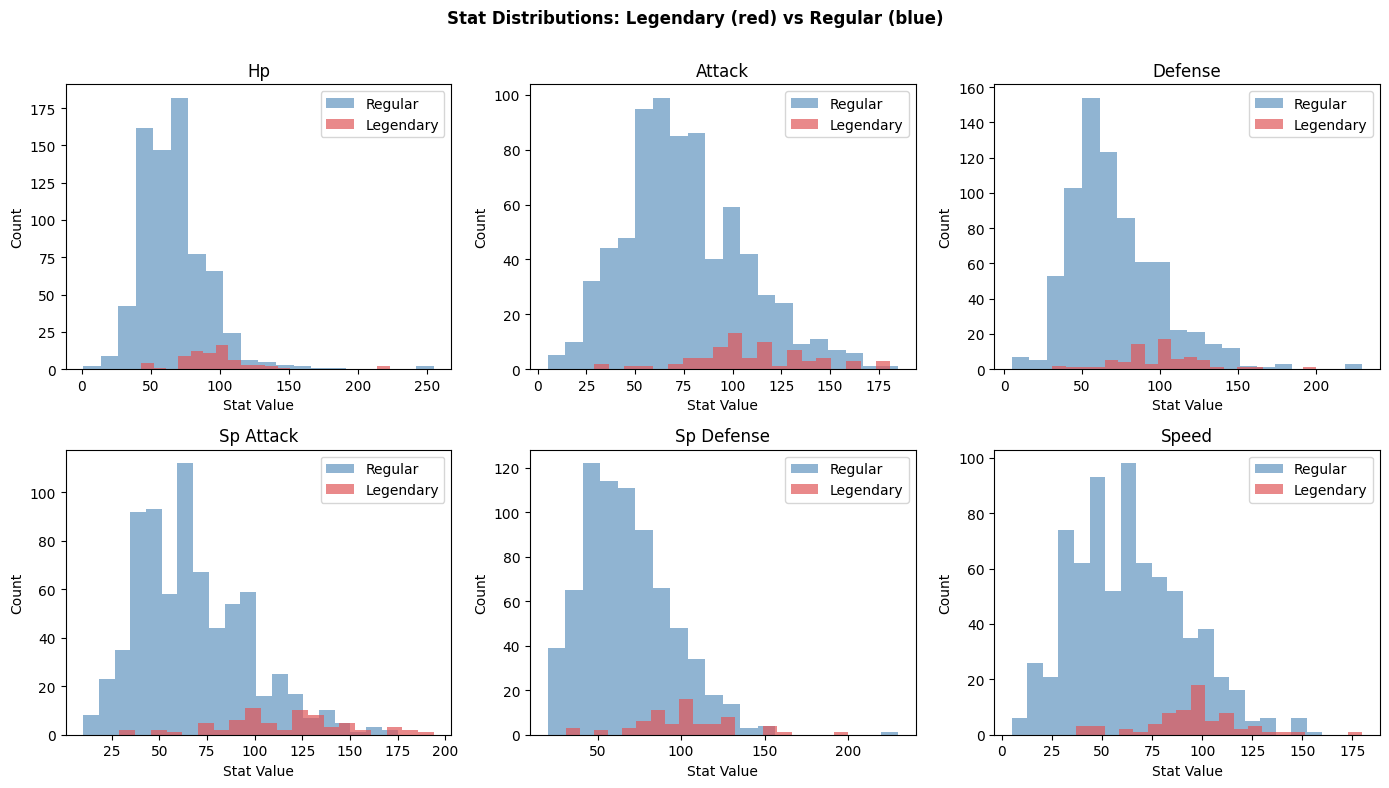

In [ ]:
#Gotta compare stats, legendary vs regular
stat_cols = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, stat in enumerate(stat_cols):
    regular   = df[df["is_legendary"] == 0][stat].dropna()
    legendary = df[df["is_legendary"] == 1][stat].dropna()
    axes[i].hist(regular,   bins=20, alpha=0.6, color="steelblue", label="Regular")
    axes[i].hist(legendary, bins=20, alpha=0.7, color="#e15759",   label="Legendary")
    axes[i].set_title(stat.replace("_", " ").title(), fontsize=12)
    axes[i].set_xlabel("Stat Value")
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle(
    "Stat Distributions: Legendary (red) vs Regular (blue)\n",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

Lucky with this dataset, the Base Stat Total is already a sum of all 6 battle stats. So it's precalculated.

<Figure size 700x500 with 0 Axes>

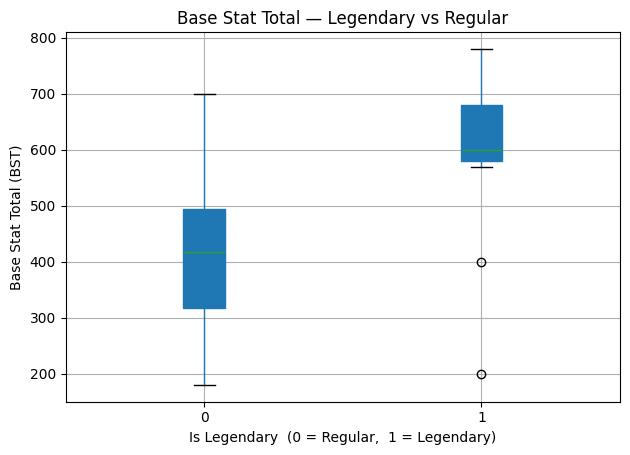

Average BST by class:
is_legendary
Regular      410.5
Legendary    615.3
Name: base_total, dtype: float64


In [ ]:
#clear separation for the total stat between Legendary and Regular
plt.figure(figsize=(7, 5))
df.boxplot(column="base_total", by="is_legendary", patch_artist=True)
plt.title("Base Stat Total — Legendary vs Regular")
plt.suptitle("")
plt.xlabel("Is Legendary  (0 = Regular,  1 = Legendary)")
plt.ylabel("Base Stat Total (BST)")
plt.tight_layout()
plt.show()

print("Average BST by class:")
print(df.groupby("is_legendary")["base_total"]
        .mean()
        .rename({0: "Regular", 1: "Legendary"})
        .round(1))

In [ ]:
#Lets clean this up
df["capture_rate"] = (
    df["capture_rate"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .pipe(pd.to_numeric, errors="coerce")  # convert to float
)

print("capture_rate after cleaning:")
print(df["capture_rate"].describe().round(2))
print(f"Any remaining NaN: {df['capture_rate'].isnull().sum()}")

# Check all missing values across the full dataset
print("\nMissing values (all columns):")
missing = df.isnull().sum()
print(missing[missing > 0])

capture_rate after cleaning:
count    801.00
mean      98.68
std       76.25
min        3.00
25%       45.00
50%       60.00
75%      170.00
max      255.00
Name: capture_rate, dtype: float64
Any remaining NaN: 0

Missing values (all columns):
height_m            20
percentage_male     98
type2              384
weight_kg           20
dtype: int64


Now to choose the Features. Important stats are

Battle stats(hp, attack, defense, sp_attack, sp_defense, speed)

base_total (pre-calculated)

base_experience(legendaries reward more xp)

capture_rate(legendaries are the hardest to catch)

base_happiness(personality)

base_egg_steps(legendaries can't breed)

base_egg_steps  — legendaries cannot breed, giving them unusual egg values
height_m

weight_kg

generation(legendary differes by generation)

against_*( 18 type-matchup multipliers, legendaries tend to be Dragon/Psychic type)

excluded type_1 & type_2 since type correlates too strongly with legendaries since they tend to be Dragon/Psychic

In [ ]:
against_cols = [c for c in df.columns if c.startswith("against_")]

features = (
    ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]
    + ["base_total"]
    + ["base_experience"]
    + ["capture_rate"]
    + ["base_happiness"]
    + ["base_egg_steps"]
    + ["height_m"]
    + ["weight_kg"]
    + ["generation"]
    + against_cols
)


features = [f for f in features if f in df.columns]

print(f"\nTotal features selected: {len(features)}")
print("Feature list:")
for f in features:
    print(f"  {f}")

# Build X (inputs) and y (target)
X = df[features].copy()
y = df["is_legendary"].astype(int)

print(f"\nX shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")



Total features selected: 31
Feature list:
  hp
  attack
  defense
  sp_attack
  sp_defense
  speed
  base_total
  capture_rate
  base_happiness
  base_egg_steps
  height_m
  weight_kg
  generation
  against_bug
  against_dark
  against_dragon
  against_electric
  against_fairy
  against_fight
  against_fire
  against_flying
  against_ghost
  against_grass
  against_ground
  against_ice
  against_normal
  against_poison
  against_psychic
  against_rock
  against_steel
  against_water

X shape: (801, 31)
y distribution:
is_legendary
0    731
1     70
Name: count, dtype: int64


In [ ]:
#clean up any potential missing values, encoding and scaler
print("Missing values before fill:")
print(X.isnull().sum()[X.isnull().sum() > 0])

X = X.fillna(X.median())

print("\nMissing values after fill:")
print(X.isnull().sum()[X.isnull().sum() > 0] if X.isnull().sum().any() else "  None ✓")

y_encoded   = y.values
num_classes = 2    # Regular (0) or Legendary (1)

print(f"\nTarget: 0 = Regular ({(y_encoded==0).sum()}), "
      f"1 = Legendary ({(y_encoded==1).sum()})")

scaler = StandardScaler()


Missing values before fill:
height_m     20
weight_kg    20
dtype: int64

Missing values after fill:
  None ✓

Target: 0 = Regular (731), 1 = Legendary (70)


In [ ]:
#Time to train! Remember 70% Train 15% Validation 15% Test
X_np = X.values

X_train, X_temp, y_train, y_temp = train_test_split(
    X_np, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

# Fit the scaler on TRAINING data only, then apply to all three sets
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_val_s   = scaler.transform(X_val)          # transform only
X_test_s  = scaler.transform(X_test)         # transform only

print(f"Training set   : {X_train_s.shape[0]:3d} Pokémon  "
      f"({y_train.mean()*100:.1f}% Legendary)")
print(f"Validation set : {X_val_s.shape[0]:3d} Pokémon  "
      f"({y_val.mean()*100:.1f}% Legendary)")
print(f"Test set       : {X_test_s.shape[0]:3d} Pokémon  "
      f"({y_test.mean()*100:.1f}% Legendary)")
print(f"Legendary should be relatively similar percentages :)")

Training set   : 560 Pokémon  (8.8% Legendary)
Validation set : 120 Pokémon  (8.3% Legendary)
Test set       : 121 Pokémon  (9.1% Legendary)
Legendary should be relatively similar percentages :)


In [ ]:
#Time for baseline
naive_acc = (y_test == 0).mean()
print(f"Naive baseline (always Regular): {naive_acc*100:.1f}%\n")


print("  BASELINE MODELS")


Naive baseline (always Regular): 90.9%

  BASELINE MODELS


So surprised by how high the baseline was.. Am i doing this right??
Hopefully with Logistic Regression model the percentage goes up but like, this is already pretty great.

In [ ]:
lr_model = LogisticRegression(
    max_iter=2000,           # more iterations to ensure convergence
    class_weight="balanced",
    random_state=42
)
lr_model = lr_model # Assign r_model to lr_model for consistency
lr_model.fit(X_train_s, y_train)
lr_preds = lr_model.predict(X_test_s)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f"\nLogistic Regression — Test Accuracy: {lr_acc*100:.1f}%")
print(classification_report(
    y_test, lr_preds,
    target_names=["Regular", "Legendary"],
    zero_division=0
))


Logistic Regression — Test Accuracy: 99.2%
              precision    recall  f1-score   support

     Regular       1.00      0.99      1.00       110
   Legendary       0.92      1.00      0.96        11

    accuracy                           0.99       121
   macro avg       0.96      1.00      0.98       121
weighted avg       0.99      0.99      0.99       121



In [ ]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_s, y_train)
rf_preds = rf_model.predict(X_test_s)
rf_acc   = accuracy_score(y_test, rf_preds)

print(f"Random Forest — Test Accuracy: {rf_acc*100:.1f}%")
print(classification_report(
    y_test, rf_preds,
    target_names=["Regular", "Legendary"],
    zero_division=0
))


Random Forest — Test Accuracy: 99.2%
              precision    recall  f1-score   support

     Regular       1.00      0.99      1.00       110
   Legendary       0.92      1.00      0.96        11

    accuracy                           0.99       121
   macro avg       0.96      1.00      0.98       121
weighted avg       0.99      0.99      0.99       121



In [ ]:
#SVM
svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True,        # needed so we can get confidence scores in the quiz
    random_state=42
)
svm_model.fit(X_train_s, y_train)
svm_preds = svm_model.predict(X_test_s)
svm_acc   = accuracy_score(y_test, svm_preds)

print(f"SVM — Test Accuracy: {svm_acc*100:.1f}%")
print(classification_report(
    y_test, svm_preds,
    target_names=["Regular", "Legendary"],
    zero_division=0
))


SVM — Test Accuracy: 97.5%
              precision    recall  f1-score   support

     Regular       0.98      0.99      0.99       110
   Legendary       0.90      0.82      0.86        11

    accuracy                           0.98       121
   macro avg       0.94      0.90      0.92       121
weighted avg       0.97      0.98      0.97       121



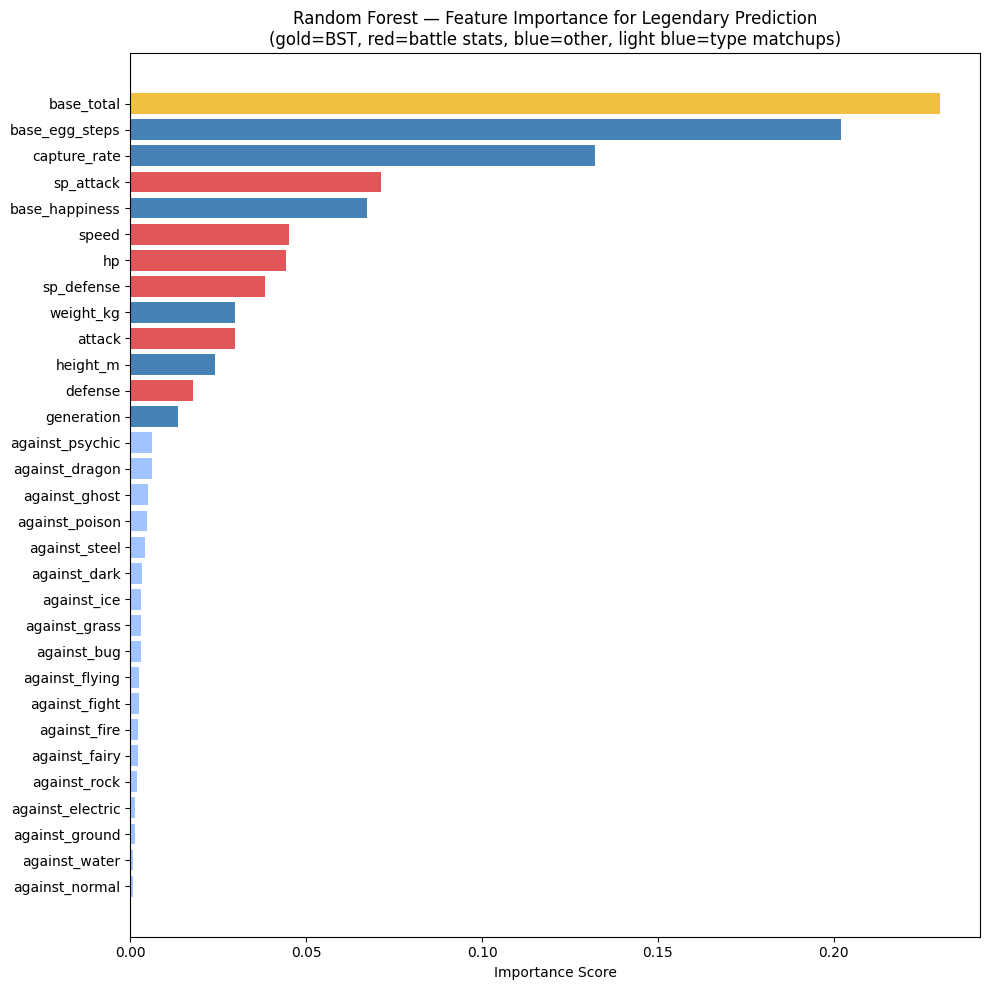

In [ ]:
#Random Forest again but Feautre importance. It'll show how each feature contributed across all 500 trees.
importance_df = pd.DataFrame({
    "Feature":    features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

# Color code: red for battle stats, gold for BST, blue for everything else
def feat_color(f):
    if f == "base_total":        return "#f0c040"
    if f in stat_cols:           return "#e15759"
    if f.startswith("against_"): return "#a0c4ff"
    return "steelblue"

bar_colors = [feat_color(f) for f in importance_df["Feature"]]

plt.figure(figsize=(10, 10))
plt.barh(importance_df["Feature"], importance_df["Importance"], color=bar_colors)
plt.title("Random Forest — Feature Importance for Legendary Prediction\n"
          "(gold=BST, red=battle stats, blue=other, light blue=type matchups)",
          fontsize=12)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
#Main model now! Please don't be at 20%

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_s,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_train_t = torch.tensor(y_train,   dtype=torch.long)
y_val_t   = torch.tensor(y_val,     dtype=torch.long)
y_test_t  = torch.tensor(y_test,    dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=32
)

#Weights
counts       = np.bincount(y_train)
raw_weights  = 1.0 / counts
norm_weights = raw_weights / raw_weights.sum()
class_weights = torch.tensor(norm_weights, dtype=torch.float32).to(device)

print(f"Class weights:")
print(f"  Regular   : {class_weights[0]:.4f}")
print(f"  Legendary : {class_weights[1]:.4f}")


Class weights:
  Regular   : 0.0875
  Legendary : 0.9125


In [ ]:
class LegendaryNet(nn.Module):
    def __init__(self, input_size):
        super(LegendaryNet, self).__init__()
        self.network = nn.Sequential(

            nn.Linear(input_size, 128),  # 27 features → 128 neurons
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),             # 40% dropout

            nn.Linear(128, 64),          # 128 → 64 neurons
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),           # 64 → 32 neurons
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),             # lighter dropout

            nn.Linear(32, 2)             # 32 → 2 output scores
        )
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
       return self.network(x)

nn_model = LegendaryNet(input_size=len(features)).to(device)

total_params = sum(p.numel() for p in nn_model.parameters() if p.requires_grad)
print(f"\nNeural Network:")
print(nn_model)
print(f"\nTrainable parameters: {total_params:,}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(nn_model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10
)


Neural Network:
LegendaryNet(
  (network): Sequential(
    (0): Linear(in_features=31, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=2, bias=True)
  )
)

Trainable parameters: 14,946


In [ ]:
NUM_EPOCHS        = 200
PATIENCE          = 20
best_val_loss     = float("inf")
epochs_no_improve = 0
best_weights      = None

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print("\nTraining neural network...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}")
print("-" * 65)

for epoch in range(NUM_EPOCHS):

    #Training!
    nn_model.train()
    run_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()              # clear gradients
        outputs = nn_model(X_batch)        # forward pass through all layers
        loss    = criterion(outputs, y_batch)  # compare outputs to true labels
        loss.backward()                    # compute gradients, backprop
        nn.utils.clip_grad_norm_(nn_model.parameters(), max_norm=1.0)
        optimizer.step()                   # update weights

        run_loss += loss.item() * X_batch.size(0)
        correct  += (outputs.argmax(dim=1) == y_batch).sum().item()
        total    += y_batch.size(0)

    train_loss = run_loss / total
    train_acc  = correct  / total

    # Validation!
    nn_model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs      = nn_model(X_batch)
            val_loss_sum += criterion(outputs, y_batch).item() * X_batch.size(0)
            val_correct  += (outputs.argmax(dim=1) == y_batch).sum().item()
            val_total    += y_batch.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:>6} | {train_loss:>10.4f} | {train_acc:>9.3f} | "
              f"{val_loss:>8.4f} | {val_acc:>7.3f} | {current_lr:>8.6f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_weights      = {k: v.clone() for k, v in nn_model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\n  Early stopping triggered at epoch {epoch + 1}.")
        print(f"  Best validation loss: {best_val_loss:.4f}")
        break

# Restore the best weights seen during training
nn_model.load_state_dict(best_weights)
print("  Best weights restored ✓")



Training neural network...
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR
-----------------------------------------------------------------
    10 |     0.2332 |     0.938 |   0.1278 |   0.967 | 0.001000
    20 |     0.1325 |     0.979 |   0.1109 |   0.975 | 0.001000
    30 |     0.0813 |     0.979 |   0.0755 |   0.983 | 0.001000
    40 |     0.0868 |     0.980 |   0.0789 |   0.983 | 0.001000
    50 |     0.0646 |     0.988 |   0.0511 |   0.983 | 0.001000
    60 |     0.1103 |     0.982 |   0.0333 |   0.983 | 0.001000
    70 |     0.0251 |     0.993 |   0.0329 |   0.992 | 0.001000
    80 |     0.0256 |     0.995 |   0.0308 |   0.983 | 0.001000
    90 |     0.0577 |     0.993 |   0.0338 |   0.983 | 0.001000
   100 |     0.0130 |     0.996 |   0.0345 |   0.992 | 0.000500

  Early stopping triggered at epoch 100.
  Best validation loss: 0.0308
  Best weights restored ✓



Neural Network — Test Accuracy : 98.3%
Neural Network — ROC AUC       : 0.9967

Detailed report:
              precision    recall  f1-score   support

     Regular       0.99      0.99      0.99       110
   Legendary       0.91      0.91      0.91        11

    accuracy                           0.98       121
   macro avg       0.95      0.95      0.95       121
weighted avg       0.98      0.98      0.98       121



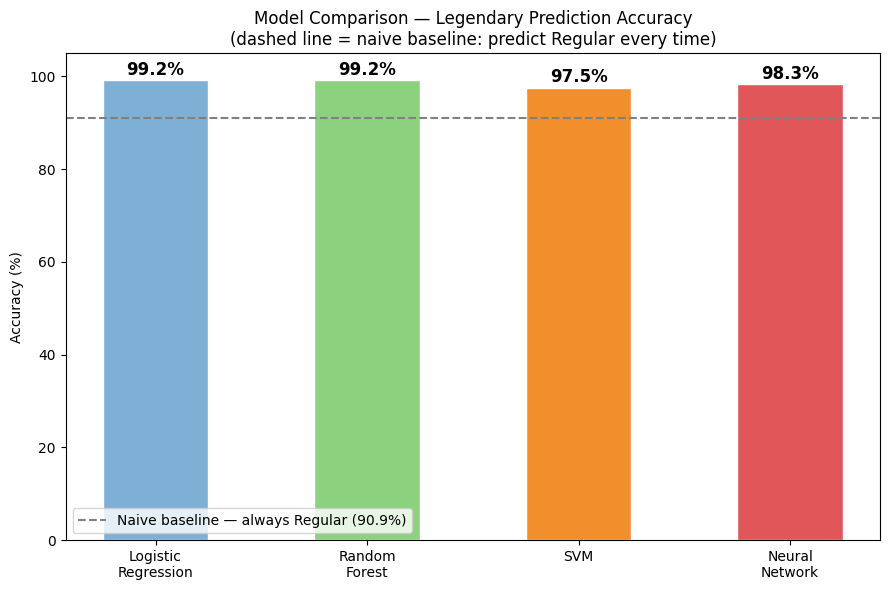


Full accuracy summary:
  Naive baseline (always Regular) : 90.9%
  Logistic Regression             : 99.2%
  Random Forest                   : 99.2%
  SVM                             : 97.5%
  Neural Network                  : 98.3%
  Neural Net AUC                  : 0.9967


In [ ]:
nn_model.eval()
with torch.no_grad():
    test_out     = nn_model(X_test_t.to(device))
    nn_probs_all = torch.softmax(test_out, dim=1).cpu().numpy()
    nn_preds     = test_out.argmax(dim=1).cpu().numpy()
    nn_probs_leg = nn_probs_all[:, 1]    # P(Legendary) for each test Pokémon

nn_acc = accuracy_score(y_test, nn_preds)
nn_auc = roc_auc_score(y_test, nn_probs_leg)

print(f"\nNeural Network — Test Accuracy : {nn_acc*100:.1f}%")
print(f"Neural Network — ROC AUC       : {nn_auc:.4f}")
print("\nDetailed report:")
print(classification_report(
    y_test, nn_preds,
    target_names=["Regular", "Legendary"],
    zero_division=0
))

# All models side by side for quick reference


all_names  = ["Logistic\nRegression", "Random\nForest", "SVM", "Neural\nNetwork"]
all_accs   = [lr_acc, rf_acc, svm_acc, nn_acc]
all_colors = ["#7eb0d5", "#8cd17d", "#f28e2b", "#e15759"]

plt.figure(figsize=(9, 6))
bars = plt.bar(all_names, [a*100 for a in all_accs],
               color=all_colors, width=0.5, edgecolor="white")
for bar, acc in zip(bars, all_accs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{acc*100:.1f}%",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

plt.axhline(
    y=naive_acc * 100,
    color="gray", linestyle="--", linewidth=1.5,
    label=f"Naive baseline — always Regular ({naive_acc*100:.1f}%)"
)
plt.legend()
plt.title("Model Comparison — Legendary Prediction Accuracy\n"
          "(dashed line = naive baseline: predict Regular every time)",
          fontsize=12)
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print("\nFull accuracy summary:")
print(f"  Naive baseline (always Regular) : {naive_acc*100:.1f}%")
print(f"  Logistic Regression             : {lr_acc*100:.1f}%")
print(f"  Random Forest                   : {rf_acc*100:.1f}%")
print(f"  SVM                             : {svm_acc*100:.1f}%")
print(f"  Neural Network                  : {nn_acc*100:.1f}%")
print(f"  Neural Net AUC                  : {nn_auc:.4f}")


         ✨  ARE YOU LEGENDARY?  ✨
Powered by the neural network we just trained.
Your Pokémon match can be any Pokémon in the dataset.

Rate yourself 1 low to 5 high on each question:

1. As a trainer, what kind of partner would you trust in a tough battle?
   1 = clever and evasive, 5 = sturdy and hard to knock out: 4

2. What battle style fits you best?
   1 = patient and strategic, 5 = powerful and aggressive: 1

3. How do you like your Pokémon to move in battle?
   1 = calm and steady, 5 = fast and unpredictable: 1

4. What kind of Pokémon would you feel most connected to?
   1 = friendly and familiar, 5 = rare and mysterious: 5

5. What kind of presence should your ideal Pokémon have?
   1 = small, cute, and loyal, 5 = massive, powerful, and legendary: 5


Verdict               : REGULAR
Model confidence      : 99.9%
Legendary probability : 0.1%
Your Pokémon match    : Lucario
Fetching sprite from PokéAPI...


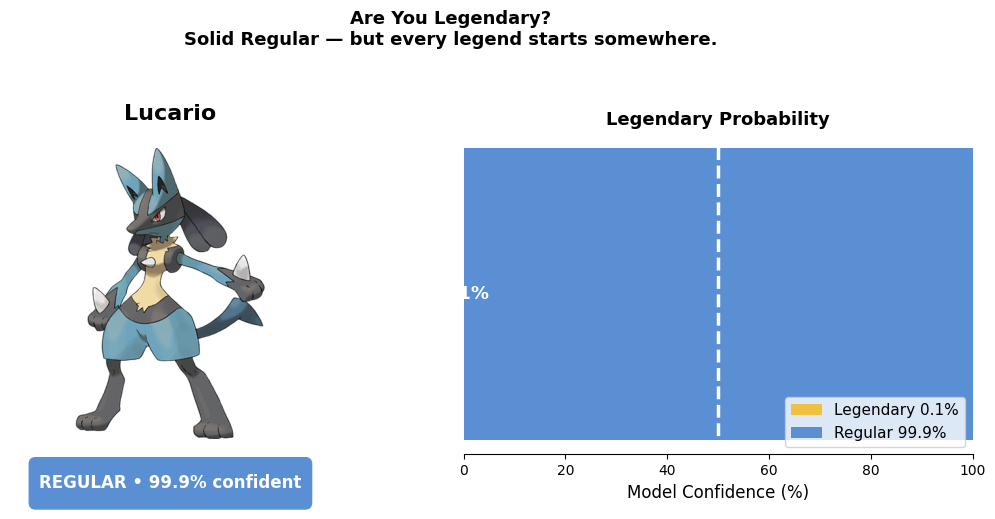

In [ ]:
#Pokemon Quiz!

LEGENDARY_COLOR = "#f0c040"
REGULAR_COLOR   = "#5a8fd4"

# Re-define features and against_cols here to ensure scope
against_cols = [c for c in df.columns if c.startswith("against_")]

features = (
    ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]
    + ["base_total"]
    + ["base_experience"]
    + ["capture_rate"]
    + ["base_happiness"]
    + ["base_egg_steps"]
    + ["height_m"]
    + ["weight_kg"]
    + ["generation"]
    + against_cols
)

features = [f for f in features if f in df.columns] # Filter out 'base_experience' if not in df


def get_pokemon_name(row):
    """
    Safely get the Pokémon name from the dataset.
    The Kaggle Pokémon dataset usually uses the column 'name'.
    """
    return str(row["name"]).lower().replace(" ", "-")


def build_pokemon_candidate_pool(pred, size_answer):
    """
    Use EVERY Pokémon in the dataset as a possible quiz result.

    pred:
      0 = Regular
      1 = Legendary

    size_answer:
      Q5 answer from 1 to 5
      1-2 = smaller Pokémon
      3   = no strong size filter
      4-5 = larger Pokémon
    """

    pool = df[df["is_legendary"] == pred].copy()

    # Use dataset-wide size percentiles so this adapts to the CSV
    height_low  = df["height_m"].quantile(0.35)
    height_high = df["height_m"].quantile(0.65)
    weight_low  = df["weight_kg"].quantile(0.35)
    weight_high = df["weight_kg"].quantile(0.65)

    if size_answer <= 2:
        pool = pool[
            (pool["height_m"] <= height_low) |
            (pool["weight_kg"] <= weight_low)
        ]
    elif size_answer >= 4:
        pool = pool[
            (pool["height_m"] >= height_high) |
            (pool["weight_kg"] >= weight_high)
        ]

    # Safety fallback: if filtering gets too strict, use all Pokémon of that class
    if len(pool) == 0:
        pool = df[df["is_legendary"] == pred].copy()

    return pool


def choose_pokemon_match(pred, leg_prob, answers):
    """
    Pick a Pokémon from the full dataset, not from a hardcoded list.

    The match is filtered by:
      - predicted legendary status
      - user's size preference from Q5

    Then it chooses a Pokémon whose base_total is close to the quiz-generated
    base_total, so stronger quiz answers tend to match stronger Pokémon.
    """

    q5 = answers[4]
    target_bst = 350 + q5 * 55

    pool = build_pokemon_candidate_pool(pred, q5).copy()

    pool["bst_distance"] = abs(pool["base_total"] - target_bst)

    # Take closest matches, then randomly choose one for variety
    top_matches = pool.sort_values("bst_distance").head(25)

    chosen = top_matches.sample(1).iloc[0]
    return get_pokemon_name(chosen)


def get_sprite(name):
    """
    Fetch official artwork from PokéAPI.
    """
    try:
        data = requests.get(
            f"https://pokeapi.co/api/v2/pokemon/{name.lower()}",
            timeout=5
        ).json()

        url = (
            data["sprites"]["other"]["official-artwork"]["front_default"]
            or data["sprites"]["front_default"]
        )

        if url:
            return Image.open(BytesIO(requests.get(url, timeout=5).content))

    except Exception:
        pass

    return None


def quiz_to_feature_vector(answers):
    """
    Convert quiz answers into a feature vector matching the model's training data.
    """

    q1, q2, q3, q4, q5 = answers

    hp          = 45 + q1 * 22
    attack      = 40 + q2 * 22
    defense     = 40 + q1 * 18
    sp_attack   = 40 + q2 * 22
    sp_defense  = 40 + q1 * 15
    speed       = 30 + q3 * 22
    base_total  = 350 + q5 * 55
    capture_rate = max(3, 200 - q4 * 50)
    height_m  = 0.4 + (q5 - 1) * 1.15
    weight_kg = 8.0 + (q5 - 1) * 60.0

    quiz_values = {
        "hp": hp,
        "attack": attack,
        "defense": defense,
        "sp_attack": sp_attack,
        "sp_defense": sp_defense,
        "speed": speed,
        "base_total": base_total,
        "capture_rate": capture_rate,
        "height_m": height_m,
        "weight_kg": weight_kg
    }

    full_vector = []

    for f in features:
        if f in quiz_values:
            full_vector.append(quiz_values[f])
        else:
            col_idx = list(features).index(f)
            full_vector.append(float(np.median(X_train[:, col_idx])))

    return full_vector


def predict_legendary_status(raw_vector):
    """
    Run quiz vector through the trained neural network.
    """

    scaled = scaler.transform(np.array(raw_vector).reshape(1, -1))
    tensor = torch.tensor(scaled, dtype=torch.float32).to(device)

    nn_model.eval()

    with torch.no_grad():
        out = nn_model(tensor)
        probs = torch.softmax(out, dim=1).squeeze().cpu().numpy()

    pred = int(np.argmax(probs))
    confidence = probs[pred] * 100
    leg_prob = probs[1] * 100

    return pred, confidence, leg_prob


def display_quiz_result(pred, confidence, leg_prob, pokemon_name):
    """
    Display result with sprite and probability gauge.
    """

    sprite = get_sprite(pokemon_name)

    is_leg = pred == 1
    badge_color = LEGENDARY_COLOR if is_leg else REGULAR_COLOR
    verdict = "LEGENDARY" if is_leg else "REGULAR"

    if sprite:
        fig, (ax_img, ax_gauge) = plt.subplots(1, 2, figsize=(11, 5))

        ax_img.imshow(sprite)
        ax_img.axis("off")
        ax_img.set_title(
            pokemon_name.replace("-", " ").title(),
            fontsize=16,
            fontweight="bold",
            pad=10
        )

        badge = mpatches.FancyBboxPatch(
            (0.08, -0.15), 0.84, 0.12,
            boxstyle="round,pad=0.02",
            transform=ax_img.transAxes,
            color=badge_color,
            zorder=5,
            clip_on=False
        )

        ax_img.add_patch(badge)

        ax_img.text(
            0.5, -0.09,
            f"{verdict} • {confidence:.1f}% confident",
            transform=ax_img.transAxes,
            ha="center",
            va="center",
            fontsize=12,
            color="white",
            fontweight="bold",
            zorder=6
        )

    else:
        fig, ax_gauge = plt.subplots(figsize=(6, 5))
        print(f"Could not load sprite for {pokemon_name}.")

    ax_gauge.barh(
        [""],
        [leg_prob],
        color=LEGENDARY_COLOR,
        height=0.4,
        label=f"Legendary {leg_prob:.1f}%"
    )

    ax_gauge.barh(
        [""],
        [100 - leg_prob],
        left=[leg_prob],
        color=REGULAR_COLOR,
        height=0.4,
        label=f"Regular {100 - leg_prob:.1f}%"
    )

    ax_gauge.axvline(x=50, color="white", linewidth=2.5, linestyle="--")
    ax_gauge.set_xlim(0, 100)
    ax_gauge.set_xlabel("Model Confidence (%)", fontsize=12)
    ax_gauge.set_title("Legendary Probability", fontsize=13, fontweight="bold")
    ax_gauge.legend(loc="lower right", fontsize=11)
    ax_gauge.spines[["top", "right", "left"]].set_visible(False)
    ax_gauge.set_yticks([])

    ax_gauge.text(
        leg_prob / 2,
        0,
        f"{leg_prob:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontsize=13,
        fontweight="bold"
    )

    message = (
        "The model sees LEGENDARY power in you!"
        if is_leg
        else
        "Solid Regular — but every legend starts somewhere."
    )

    plt.suptitle(
        f"Are You Legendary?\n{message}",
        fontsize=13,
        fontweight="bold",
        y=1.05
    )

    plt.tight_layout()
    plt.show()


def run_quiz():
    """
    Interactive quiz using the trained neural network.
    Pokémon match now comes from the full dataset.
    """

    print("\n" + "=" * 60)
    print("         ✨  ARE YOU LEGENDARY?  ✨")
    print("=" * 60)
    print("Powered by the neural network we just trained.")
    print("Your Pokémon match can be any Pokémon in the dataset.\n")
    print("Rate yourself 1 low to 5 high on each question:\n")

    questions = [
        ("1. As a trainer, what kind of partner would you trust in a tough battle?\n"
         "   1 = clever and evasive, 5 = sturdy and hard to knock out: "),

        ("2. What battle style fits you best?\n"
         "   1 = patient and strategic, 5 = powerful and aggressive: "),

        ("3. How do you like your Pokémon to move in battle?\n"
         "   1 = calm and steady, 5 = fast and unpredictable: "),

        ("4. What kind of Pokémon would you feel most connected to?\n"
         "   1 = friendly and familiar, 5 = rare and mysterious: "),

        ("5. What kind of presence should your ideal Pokémon have?\n"
         "   1 = small, cute, and loyal, 5 = massive, powerful, and legendary: ")
    ]

    answers = []

    for q in questions:
        while True:
            try:
                val = int(input(q))

                if 1 <= val <= 5:
                    answers.append(val)
                    print()
                    break
                else:
                    print("Please enter a number from 1 to 5.\n")

            except ValueError:
                print("Please enter a whole number.\n")

    vector = quiz_to_feature_vector(answers)
    pred, confidence, leg_prob = predict_legendary_status(vector)

    pokemon = choose_pokemon_match(pred, leg_prob, answers)

    print(f"\nVerdict               : {'LEGENDARY' if pred == 1 else 'REGULAR'}")
    print(f"Model confidence      : {confidence:.1f}%")
    print(f"Legendary probability : {leg_prob:.1f}%")
    print(f"Your Pokémon match    : {pokemon.replace('-', ' ').title()}")
    print("Fetching sprite from PokéAPI...")

    display_quiz_result(pred, confidence, leg_prob, pokemon)


run_quiz()